In [1]:
import matplotlib.pyplot as plt
import os
from pathlib import Path
from importlib import reload

os.chdir("..")  # Change root dir to project folder
os.getcwd()

import plotting.paper_plots_II as pp

# Slide Plots

In [ ]:
# Imports
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import utils.paths as paths
import data.transforms as trfs
import data.datasets as datasets
import data.segment as seg
import plotting.image_plots as imgplt
import plotting.plot_utils as putil

# Set up global variables
out_path = paths.ANALYSIS_PARENT / "slides_plots/KISS_Meeting_25"

mm = 1 / 25.4  # mm in inches
fig_width = 88 * mm
seed = 42

## Multi-Step Schematic Overview

In [ ]:
# T-RECS Catalog
trecs_file = Path(
    "/hs/fs08/data/group-brueggen/tmartinez/diffusion/sky_maps/map_5deg_v4.1/trecs/catalogue_continuum_wrapped.fits"
)

from astropy.table import Table

trecs_df = Table.read(trecs_file, hdu=1, unit_parse_strict="silent").to_pandas()

trecs_df[["x_coord", "y_coord", "size", "I144"]]

In [ ]:
uv_stacked.shape, visibilities.shape, S.shape

In [ ]:
# Measurment Set
ms_file = Path(
    "/hs/fs08/data/group-brueggen/tmartinez/diffusion/sky_maps/map_5deg_v4.1/synthms/map_5deg_v4.1_synth_DP3avg_SB001_121MHz.MS"
)

from casacore.tables import table
import matplotlib.pyplot as plt

obs_tb = table(str(ms_file), ack=False)
uv_stacked = obs_tb.getcol("UVW")
visibilities = obs_tb.getcol("DATA")
S = (1 / np.sqrt(2)) * np.array(
    [[1, 1, 0, 0], [0, 0, 1, 1j], [0, 0, 1, -1j], [1, -1, 0, 0]], dtype=np.complex128
)
visibilities = visibilities @ S

plt.scatter(
    uv_stacked[:, 0], uv_stacked[:, 1], c=np.abs(visibilities[:, -1, -1]), s=0.1
)
plt.xlabel("u [m]")
plt.ylabel("v [m]")
plt.colorbar()
plt.show()

## Training Data

### All Cutouts & Sigma-SNR

In [ ]:
# Plot Selection of all cutouts
print("Plotting all cutouts...")

n_rows = 4
n_cols = 10

n_imgs = n_rows * n_cols
cutouts_file = Path(
    "/hs/fs08/data/group-brueggen/tmartinez/image_data/LOFAR/cutouts/cutouts_200p_optC.hdf5"
)
with h5py.File(cutouts_file, "r") as f:
    imgs = f["cutouts"]
    idxs = np.random.RandomState(seed=seed).choice(len(imgs), size=n_imgs)
    print("Reading...")
    imgs = np.array(imgs[np.sort(idxs)])

fig, _ = imgplt.plot_image_grid(
    trfs.minmax_scale_batch(imgs), vmin=0, vmax=1, n_cols=n_cols
)
# fig.savefig(out_path / "Image_Example_Grids_All-Cutouts.pdf")
fig.show()

In [ ]:
cutouts_df = pd.read_hdf(cutouts_file, key="catalog")
cutouts_df = cutouts_df[cutouts_df.Problem_cutout == 0].reset_index(drop=True)

In [ ]:
SNR = cutouts_df.Sigma_SNR.values

edges = np.linspace(0, 8, 9)
counts = np.histogram(SNR, bins=edges)[0]

# Pick n_row examples from each bin
n_row = 5
n_col = len(edges) - 1
binned_idxs = np.digitize(SNR, edges)  # Bin index for every SNR value
bin_idxs = np.arange(0, n_col) + 1
all_idxs = [np.argwhere(binned_idxs == i_bin).flatten() for i_bin in bin_idxs]
img_idxs = [
    (
        np.random.RandomState(seed=8).choice(ii, n_row, replace=False)
        if len(ii) > 0
        else []
    )
    for ii in all_idxs
]

# Load only those images from the file
imgs = []
with h5py.File(cutouts_file, "r") as f:
    for ii in img_idxs:
        row = []
        for idx in ii:
            row.append(f["cutouts"][idx])
        imgs.append(row)

In [ ]:
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

%matplotlib ipympl
# SNR Example Plot
fig = plt.figure(
    dpi=150,
    figsize=(fig_width * 1.5, fig_width * 4 / 3 * 0.9 * 1.5),
    tight_layout=True,
)

gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1])
ax0 = fig.add_subplot(gs[0])

# Make grid on the bottom
gs_lower = gridspec.GridSpecFromSubplotSpec(
    n_row, n_col, subplot_spec=gs[1], wspace=0.05, hspace=0.05
)

# Make 2D grid with axes
grid_axs = []
for i in range(n_row):
    for j in range(n_col):
        ax = fig.add_subplot(gs_lower[i, j])
        ax.axis("off")
        grid_axs.append(ax)
grid_axs = np.array(grid_axs).reshape(n_row, n_col)

# Plot the distribution
putil.add_distribution_plot(
    counts,
    edges,
    ax0,
    color="black",
    alpha=0.8,
    normalize=False,
    label="Cutouts",
    label_count=False,
)
ax0.axvline(5, color="grey", linestyle="--", label="Sel. cut")
ax0.set_xlabel(r"$\mathit{S/N}_\sigma$")
ax0.set_ylabel("Count")
# Set ticks format to abbreviate thousands
tick_formatter = lambda x, _: f"{x_red:.0f}k" if (x_red := x / 1e3) >= 1 else f"{x:.0f}"
ax0.yaxis.set_major_formatter(plt.FuncFormatter(tick_formatter))

# Plot inset with entire distribution
ax_inset = inset_axes(ax0, width="35%", height="35%", loc="upper right")
ax_inset.hist(SNR, bins=25, color="black", alpha=0.8)
ax_inset.set_yscale("log")
ax_inset.yaxis.set_major_formatter(plt.FuncFormatter(tick_formatter))

ax0.legend(loc='upper left')

for i, row in enumerate(imgs):
    for j, img in enumerate(row):
        ax = grid_axs[j, i]
        ax.imshow(img.squeeze())
        ax.axis("off")

fig.savefig(out_path / "Image_Example_Grids_SNR-Cutouts.pdf")

### Pre-Selection & Cuts

In [ ]:
# Cutouts init. Selection
file = paths.LOFAR_SUBSETS["200p"]
with h5py.File(file, "r") as f:
    imgs = f["images"]
    idxs = np.random.RandomState(seed=seed).choice(len(imgs), size=20)
    print("Reading...")
    imgs = np.array(imgs[np.sort(idxs)])

%matplotlib inline
fig, _ = imgplt.plot_image_grid(trfs.minmax_scale_batch(imgs), vmin=0, vmax=1, n_cols=5)
fig.show()

In [ ]:
cutout_idxs = [44193, 45050, 36849, 109451]

for cutout_index in cutout_idxs:

    dset_file = paths.LOFAR_SUBSETS["200p"]

    with h5py.File(dset_file, "r") as f:
        img = np.array(f["images"][cutout_index]).squeeze()
        bdsf_mask = np.array(f["island_labels"][cutout_index])

    img = trfs.minmax_scale(img)
    smoothed_mask = seg.smooth_mask(bdsf_mask)
    refined_mask = seg.refine_mask(img, smoothed_mask)

    fig, axs = plt.subplots(3, 3, figsize=(2 * fig_width,) * 2, tight_layout=True)

    for ax in axs.flatten():
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["bottom"].set_visible(False)
        ax.spines["left"].set_visible(False)
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    for aa in axs.T:
        aa[0].imshow(img)

    for j, mask in enumerate([bdsf_mask.astype(bool), smoothed_mask, refined_mask]):
        axs[0][j].contour(
            mask, levels=[0.5], colors="orange", linewidths=0.5, alpha=0.9
        )
        axs[1][j].imshow(img * mask)
        axs[2][j].imshow(img * (1 - mask))

    # Set titles
    axs[0][0].set_xlabel(f"PyBDSF Islands")
    axs[0][1].set_xlabel("Smoothed Mask")
    axs[0][2].set_xlabel("Refined Mask")
    for ax in axs[0]:
        ax.xaxis.set_label_position("top")

    # Set ylabels
    axs[0][0].set_ylabel("Original Cutout")
    axs[1][0].set_ylabel("Mask Applied")
    axs[2][0].set_ylabel("Inverse Mask Applied")

    fig.show()

### Final Prototypes

In [ ]:
# Prototypes
print("Plotting prototypes...")
seed = 42
proto_dset = datasets.LOFARPrototypesDataset(
    "prototypes",
    train_mode=False,
    img_size=80,
)

In [ ]:
import data.datasets as datasets

idxs = np.random.RandomState(seed=69).choice(len(proto_dset), size=25)
fig, _ = proto_dset.plot_image_grid(idxs, n_cols=5, show_titles=False)
# fig.savefig(out_path / "Image_Example_Grids_Prototypes.pdf")
fig.show()

In [ ]:
# Plot a few single examples
for i in idxs:
    fig, axs = plt.subplots(1, 2, dpi=80)
    for ax in axs:
        ax.set_axis_off()
    # fig.subplots_adjust(0,0,1.5,1.5)

    ax = axs[0]
    ax.imshow(proto_dset.data[i].squeeze())

    ax = axs[1]
    img = proto_dset.data[i].squeeze().numpy()
    mask = proto_dset.masks[i].squeeze().numpy().astype(bool)
    print(img[mask].max(), img[mask].min())
    img_sc = (img - img[mask].min()) / (img[mask].max() - img[mask].min())
    ax.imshow(img_sc)

## Generated Samples

In [ ]:
samples_dset = datasets.SamplesDataset(
    "Prototypes_Model_SizeCond", key="samples_Size-Conditioned"
)

In [ ]:
import data.segment

reload(data.segment)

from data.segment import get_sample_mask, circular_mask
from tqdm import tqdm

seed = 42
n_img = 25

idxs = np.random.RandomState(seed=seed).choice(len(samples_dset), size=n_img)
imgs = trfs.max_scale_batch(samples_dset.data.numpy().squeeze()[idxs])
masks = np.array(
    [
        get_sample_mask(img, dilate=0, expand=False, smooth=True)
        for img in tqdm(imgs, desc=f"{'Sample source masks':<30}")
    ]
)
fig, _ = imgplt.plot_image_grid(imgs, masks=masks, n_cols=5, vmin=0, vmax=1)

fig.show()

In [ ]:
# Plot a few single examples
for img in imgs:
    fig, ax = plt.subplots(1, 1, dpi=80)
    ax.set_axis_off()
    ax.imshow(img)

In [ ]:
samples_dset.sampling_steps.shape

In [ ]:
25 // 6

In [ ]:
# Show sampling steps
n_steps = 26
n_examples = 15

fig, axss = plt.subplots(
    n_examples, n_steps, dpi=80, figsize=(n_steps, n_examples), constrained_layout=True
)

for i, axs in zip(idxs[:n_examples], axss):
    steps = samples_dset.sampling_steps[i].squeeze()
    steps_sel = np.stack(
        [steps[0]]
        + list(steps[1:-1][:: (len(steps) - 2) // (n_steps - 2)])
        + [steps[-1]],
        axis=0,
    )

    for ax, img in zip(axs, steps_sel):
        ax.set_axis_off()
        ax.imshow(img)

In [ ]:
from data.segment import circular_mask

circle = circular_mask(imgs.shape[1:])

for img, mask in zip(imgs, masks):

    fig, axs = plt.subplots(1, 2, figsize=(8, 4))

    ax = axs[0]
    ax.imshow(img.squeeze())
    ax.contour(mask.squeeze(), levels=[0.5], colors="red", linewidths=1)
    ax.contour(circle, levels=[0.5], colors="blue", linewidths=1)

    ax = axs[1]
    background = (img * (1 - mask)).squeeze()
    ax.imshow(background)
    bg_mask = (1 - mask).squeeze().astype(bool)
    print(
        background[bg_mask].min(),
        background[bg_mask].max(),
        np.sqrt(np.mean(background[bg_mask] ** 2)),
    )

    for ax in axs:
        ax.axis("off")

    fig.show()

# Tables

## PyBDSF Settings

In [ ]:
import pandas as pd

from analysis.bdsf_on_map import standard_settings

df = pd.DataFrame(standard_settings)

print(
    df.to_latex(
        index=False,
    )
    .replace("\\toprule", "\\hline")
    .replace("\\midrule", "\\hline\\hline")
    .replace("\\bottomrule", "\\hline")
)

# Data Selection

## Seleciton Counts Barchart

In [ ]:
reload(pp)

pp.training_data_selection_barchart()

## Example Grids

In [ ]:
reload(pp)

pp.image_example_grids()

## Mask Post-Processing

In [ ]:
reload(pp)

pp.mask_post_processing()

## Edge Relative Maximum Dropouts

In [ ]:
reload(pp)

pp.mask_edge_threshold_dropouts()

# Results

## Example Map Plots

In [ ]:
import plotting.map_plots

reload(plotting.map_plots)
reload(pp)

pp.map_images(save=False)

In [ ]:
import plotting.map_plots

reload(plotting.map_plots)
reload(pp)

fig, axs = pp.map_vs_lotss_image(save=True)

In [ ]:
for ax in axs:
    print(ax.get_position())

### Development

In [ ]:
from maps.map_utils import get_image
from matplotlib.colors import SymLogNorm
from plotting.map_plots import double_map_plot
import utils.paths as paths
import numpy as np

map_name = "map_5deg_v4.1"
pointing_name = "P181+40"
n_deg = 0.5

# Load map and model images
map_img, map_wcs = get_image(
    paths.SKY_MAP_PARENT / map_name / f"ddf/{map_name}.int.restored.fits"
)
map_img *= 1e3

pointing_dir = paths.LOFAR_DATA_PARENT / f"pointings/{pointing_name}"
lotss_file = pointing_dir / "mosaic-blanked.fits"
lotss_arr, lotss_wcs = get_image(lotss_file)
lotss_arr *= 1e3


def center_cutout(n_deg, img, wcs):
    img = img.squeeze()
    n_px = int(n_deg * 3600 / 1.5)
    N = img.shape[0]
    n1 = (N - n_px) // 2
    n2 = n1 + n_px
    img = img[n1:n2, n1:n2]
    wcs = wcs[n1:n2, n1:n2]
    return img, wcs


lotss_arr_cut, lotss_wcs_cut = center_cutout(n_deg, lotss_arr.squeeze(), lotss_wcs)
map_arr_cut, map_wcs_cut = center_cutout(n_deg, map_img.squeeze(), map_wcs)

imgs_flat = np.concatenate([lotss_arr_cut.flatten(), map_arr_cut.flatten()])

# Color normalization
# Base linthr on max. tile RMS value of 0.153 mJy/beam
rms = 0.153
linthresh = rms
clip_quantile = 0.999
vmin = np.quantile(imgs_flat[imgs_flat < 0], clip_quantile)
vmax = np.quantile(imgs_flat[imgs_flat > 0], clip_quantile)
norm_map = SymLogNorm(
    # linthresh=norm_quantile,
    linthresh=linthresh,
    vmin=vmin,
    vmax=vmax,
    clip=True,
)

mm = 1 / 25.4  # mm in inches
fig_width = 88 * mm

fig, axs = double_map_plot(
    lotss_arr_cut,
    map_arr_cut,
    wcs=(lotss_wcs_cut, map_wcs_cut),
    size=(2 * fig_width, fig_width),
    norm=norm_map,
    cbar_label="Flux Density (mJy/beam)",
)
title_kw = dict(style="italic", weight="bold")
axs[0].set_title("LoTSS-DR2:", **title_kw)
axs[1].set_title("Simulated:", **title_kw)


# Inset zoom plot
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset


def center_cutout_arrlim(n_deg, arr):
    n_px = int(n_deg * 3600 / 1.5)
    N = arr.shape[0]
    n1 = (N - n_px) // 2
    n2 = n1 + n_px
    return n1, n2


n_deg_inset = 0.1
axins = zoomed_inset_axes(axs[0], 5, loc="upper right")
axins.imshow(lotss_arr_cut, norm=norm_map)

# sub region of the original image
n1, n2 = center_cutout_arrlim(n_deg_inset, lotss_arr_cut)
axins.set_xlim(n1, n2)
axins.set_ylim(n1, n2)

# fig.show()

In [ ]:
from maps.map_utils import get_image
from matplotlib.colors import SymLogNorm
from plotting.map_plots import double_map_plot, plot_sky_map
import utils.paths as paths
import numpy as np

pointing_name = "P181+40"
n_deg = 0.5

pointing_dir = paths.LOFAR_DATA_PARENT / f"pointings/{pointing_name}"
lotss_file = pointing_dir / "mosaic-blanked.fits"
lotss_arr, lotss_wcs = get_image(lotss_file)
lotss_arr *= 1e3


def center_cutout(n_deg, img, wcs):
    img = img.squeeze()
    n_px = int(n_deg * 3600 / 1.5)
    N = img.shape[0]
    n1 = (N - n_px) // 2
    n2 = n1 + n_px
    img = img[n1:n2, n1:n2]
    wcs = wcs[n1:n2, n1:n2]
    return img, wcs


lotss_arr_cut, lotss_wcs_cut = center_cutout(n_deg, lotss_arr.squeeze(), lotss_wcs)
imgs_flat = lotss_arr_cut.ravel()

# Color normalization
# Base linthr on max. tile RMS value of 0.153 mJy/beam
rms = 0.153
linthresh = rms
clip_quantile = 0.999
vmin = np.quantile(imgs_flat[imgs_flat < 0], clip_quantile)
vmax = np.quantile(imgs_flat[imgs_flat > 0], clip_quantile)
norm_map = SymLogNorm(
    # linthresh=norm_quantile,
    linthresh=linthresh,
    vmin=vmin,
    vmax=vmax,
    clip=True,
)

mm = 1 / 25.4  # mm in inches
fig_width = 88 * mm

In [ ]:
%matplotlib inline
fig_ax = plt.subplots(
    figsize=(9, 9),
    subplot_kw={"projection": lotss_wcs_cut},
    constrained_layout=True,
)

fig, ax, im = plot_sky_map(
    lotss_arr_cut,
    wcs=lotss_wcs_cut,
    size=(fig_width, fig_width),
    norm=norm_map,
    cbar_label="Flux Density (mJy/beam)",
    fig_ax=fig_ax,
    cbar=True,
)

# cax = ax.inset_axes([1.02, 0, 0.05, 1])
# fig.colorbar(im, cax=cax, fraction=0.046, pad=0.05, label="Flux Density (mJy/beam)")
 
# Inset zoom plot
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

def center_cutout_arrlim(n_deg, arr):
    n_px = int(n_deg * 3600 / 1.5)
    N = arr.shape[0]
    n1 = (N - n_px) // 2
    n2 = n1 + n_px
    return n1, n2

def inset_bbox(ref_ax, rel_size=0.3, borderpad=0.05):
    dpi = ref_ax.figure.get_dpi()
    figw = ref_ax.figure.get_figwidth() * dpi  # In pixels
    figh = ref_ax.figure.get_figheight() * dpi  # In pixels 
    print(dpi, figw, figh)
    ax_bbox = ref_ax.get_window_extent(fig.canvas.get_renderer()).get_points().T
    x0, x1 = ax_bbox[0] / figw
    y0, y1 = ax_bbox[1] / figh
    inset_width = rel_size * x1 # % of ax width
    inset_height = rel_size * y1  # % of ax height
    inset_x = x0 + borderpad * x1  # Align bottom-right with a small padding
    inset_y = y0 + borderpad * y1  # Small padding from bottom
    print(inset_x, inset_y, inset_width, inset_height)
    return [inset_x, inset_y, inset_width, inset_height]

n_deg_inset = 0.05
# sub region of the original image

# ax_inset = fig.add_axes(inset_bbox(ax, rel_size=0.3, borderpad=0.01), projection=lotss_wcs_cut)
ax_inset = ax.inset_axes([0.01, 0.01, 0.3, 0.3], projection=lotss_wcs_cut)
ax_inset.imshow(lotss_arr_cut, norm=norm_map)

n1, n2 = center_cutout_arrlim(n_deg_inset, lotss_arr_cut)
ax_inset.set_xlim(n1, n2)
ax_inset.set_ylim(n1, n2)

for c in ax_inset.coords:
    c.set_ticks_visible(False)
    c.set_ticklabel_visible(False)
    c.set_axislabel("")

ax_inset.spines['top'].set_visible(False)
ax_inset.set(frame_on=False)

mark_inset(ax, ax_inset, loc1=2, loc2=4, fc="none", ec="red", lw=1, alpha=0.5, ls='--')

fig.show()

In [ ]:
help(ax.coords[0])

In [ ]:
help(ax_inset.spines["top"])

In [ ]:
ax.get_tightbbox(fig.canvas.get_renderer()), ax.get_position()

In [ ]:
bbox = ax.get_tightbbox(fig.canvas.get_renderer()).get_points().T
figw = ax.figure.get_figwidth() * ax.figure.dpi  # In pixels
figh = ax.figure.get_figheight() * ax.figure.dpi  # In pixels

bbox[0] / figw, bbox[1] / figh

In [ ]:
help(ax.get_tightbbox(fig.canvas.get_renderer()))

In [ ]:
help(fig)

In [ ]:
help(ax)

In [ ]:
ax.transAxes.transform((1, 1))

In [ ]:
from maps.map_utils import get_image, beam_solid_angle
import utils.paths as paths
import numpy as np
from matplotlib.colors import SymLogNorm

map_name = "map_5deg_v4.1"

# Load map and model images
map_img, map_wcs = get_image(
    paths.SKY_MAP_PARENT / map_name / f"ddf/{map_name}.int.restored.fits"
)

model_img, model_wcs = get_image(paths.SKY_MAP_PARENT / map_name / f"{map_name}.fits")

model_img *= beam_solid_angle(6) / 1.5**2 * 1e3

# Scale map image from Jy/Beam to mJy/Beam
map_img *= 1e3

imgs_flat = np.concatenate([m.flatten() for m in [model_img, map_img]])

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(6, 3))

clip_quantile = 0.999
vmin = np.quantile(imgs_flat[imgs_flat < 0], clip_quantile)
vmax = np.quantile(imgs_flat[imgs_flat > 0], clip_quantile)
# Base linthr on max. tile RMS value of 0.153 mJy/beam
rms = 0.153
linthresh = 1 * rms

norm_map = SymLogNorm(
    # linthresh=norm_quantile,
    linthresh=linthresh,
    vmin=vmin,
    vmax=vmax,
    clip=True,
)

ax = axs[0]
print("Model hist...")
model_normed = norm_map(model_img.flatten())
ax.hist(model_normed, bins=100, histtype="step", color="blue", label="Model")

ax = axs[1]
print("Map hist...")
map_normed = norm_map(map_img.flatten())
ax.hist(map_normed, bins=100, histtype="step", color="orange", label="Map")


for ax in axs:
    ax.set_yscale("log")
    ax.legend()

fig.show()

In [ ]:
from plotting.map_plots import plot_sky_map

plot_sky_map(
    map_img,
    wcs=map_wcs,
    norm=norm_map,
)

In [ ]:
def center_cutout(n_deg, img, wcs):
    img = img.squeeze()
    n_px = int(n_deg * 3600 / 1.5)
    N = img.shape[0]
    n1 = (N - n_px) // 2
    n2 = n1 + n_px
    img = img[n1:n2, n1:n2]
    wcs = wcs[n1:n2, n1:n2]
    return img, wcs

In [ ]:
import wget


def download_pointing(pointing_name):
    link_root = "https://lofar-surveys.org/public/DR2/mosaics"
    dl_keys = ["mosaic-blanked", "mosaic.resid", "mosaic.rms"]
    fits_name = lambda key: f"{key}.fits"

    dl_dir = paths.LOFAR_DATA_PARENT / "pointings" / pointing_name
    if dl_dir.exists() and all([(dl_dir / fits_name(k)).exists() for k in dl_keys]):
        print("Pointing already loaded.")
        return

    dl_dir.mkdir(exist_ok=True)

    for key in dl_keys:
        link = f"{link_root}/{pointing_name}/{fits_name(key)}"
        out = dl_dir / fits_name(key)
        if out.exists():
            print(f"File {out} already exists.")
            continue
        print(f"Downloading {link}...")
        wget.download(link, out=str(out))

In [ ]:
import utils.paths as paths

reload(paths)
import plotting.map_plots as mpplt

reload(mpplt)
import numpy as np

pointing_name = "P181+40"

download_pointing(pointing_name)


pointing_dir = paths.LOFAR_DATA_PARENT / f"pointings/{pointing_name}"
prv_arr, prv_wcs = center_cutout(2.5, *get_image(pointing_dir / "mosaic.resid.fits"))

mpplt.plot_sky_map(
    prv_arr,
    wcs=prv_wcs,
    norm_quantile=0.995,
)


lotss_file = pointing_dir / "mosaic-blanked.fits"
lotss_arr, lotss_wcs = get_image(lotss_file)
lotss_arr *= 1e3

for n_deg in [2.5, 1, 0.5]:

    lotss_arr_cut, lotss_wcs_cut = center_cutout(n_deg, lotss_arr.squeeze(), lotss_wcs)
    map_arr_cut, map_wcs_cut = center_cutout(n_deg, map_img.squeeze(), map_wcs)

    imgs_flat = np.concatenate([lotss_arr_cut.flatten(), map_arr_cut.flatten()])

    # Color normalization
    # Base linthr on max. tile RMS value of 0.153 mJy/beam
    rms = 0.153
    linthresh = rms
    clip_quantile = 0.999
    vmin = np.quantile(imgs_flat[imgs_flat < 0], clip_quantile)
    vmax = np.quantile(imgs_flat[imgs_flat > 0], clip_quantile)
    norm_map = SymLogNorm(
        # linthresh=norm_quantile,
        linthresh=linthresh,
        vmin=vmin,
        vmax=vmax,
        clip=True,
    )

    mm = 1 / 25.4  # mm in inches
    fig_width = 88 * mm

    mpplt.double_map_plot(
        lotss_arr_cut,
        map_arr_cut,
        wcs=(lotss_wcs_cut, map_wcs_cut),
        size=(2 * fig_width, fig_width),
        norm=norm_map,
        cbar_label="Flux Density (mJy/beam)",
    )

In [ ]:
np.sqrt(np.mean(prv_arr**2))

In [ ]:
from plotting.plot_utils import auto_log_bins

plt.hist(
    prv_arr.flatten(),
    bins=auto_log_bins([prv_arr.flatten()]),
    histtype="step",
    color="blue",
    log=True,
)
plt.xscale("log")

In [ ]:
with fits.open(pointing_dir / "mosaic.rms.fits") as hdul:
    print(hdul.info())
    display(hdul[0].header)

In [ ]:
import utils.paths as paths

reload(paths)
import plotting.map_plots as mpplt

reload(mpplt)
import numpy as np

lotss_file = paths.MOSAIC_DIR / "P202+42/mosaic-blanked.fits"
lotss_arr, lotss_wcs = get_image(lotss_file)
lotss_arr *= 1e3


def center_cutout(n_deg, img, wcs):
    n_px = int(n_deg * 3600 / 1.5)
    N = img.squeeze().shape[0]
    n1 = (N - n_px) // 2
    n2 = n1 + n_px
    img = img[n1:n2, n1:n2]
    wcs = wcs[n1:n2, n1:n2]
    return img, wcs


n_deg = 0.5

from scipy.ndimage import gaussian_filter

blur_kw = dict(sigma=4 / 2.355, mode="constant")

lotss_arr_cut, lotss_wcs_cut = center_cutout(n_deg, lotss_arr.squeeze(), lotss_wcs)
lotss_arr_cut = gaussian_filter(lotss_arr_cut, **blur_kw)
map_arr_cut, map_wcs_cut = center_cutout(n_deg, map_img.squeeze(), map_wcs)

imgs_flat = np.concatenate([lotss_arr_cut.flatten(), map_arr_cut.flatten()])

clip_quantile = 0.999
vmin = np.quantile(imgs_flat[imgs_flat < 0], clip_quantile)
vmax = np.quantile(imgs_flat[imgs_flat > 0], clip_quantile)
# Base linthr on max. tile RMS value of 0.153 mJy/beam
rms = 0.153
linthresh = 1 * rms
norm_map = SymLogNorm(
    # linthresh=norm_quantile,
    linthresh=linthresh,
    vmin=vmin,
    vmax=vmax,
    clip=True,
)

mm = 1 / 25.4  # mm in inches
fig_width = 88 * mm

mpplt.double_map_plot(
    lotss_arr_cut,
    map_arr_cut,
    wcs=(lotss_wcs_cut, map_wcs_cut),
    size=(2 * fig_width, fig_width),
    norm=norm_map,
    cbar_label="Flux Density (mJy/beam)",
)

In [ ]:
from astropy.io import fits

# Show contents of lotss file
with fits.open(lotss_file) as hdul:
    display(hdul.info())

In [ ]:
from plotting.plot_utils import auto_log_bins
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 1, figsize=(6, 8))

map_px_flat = map_img.flatten()

ax = axs[0]
px_pos = map_px_flat[map_px_flat > 0]
bins = auto_log_bins(
    [
        px_pos,
    ],
    100,
)
ax.hist(px_pos, bins=bins, log=True)
ax.set_title("Pixel histogram")
ax.set_xlabel("Pixel value")
ax.set_ylabel("Number of pixels")
ax.set_xscale("log")

ax = axs[1]
px_neg = -map_px_flat[map_px_flat < 0]
bins = auto_log_bins(
    [
        px_neg,
    ],
    100,
)
ax.hist(px_neg, bins=bins, log=True)
ax.set_title("Negative pixel histogram")
ax.set_xlabel("Negative pixel value")
ax.set_ylabel("Number of pixels")
# Set axis from right to left
ax.invert_xaxis()
ax.set_xscale("log")

for ax in axs:
    ax.grid(alpha=0.3)

fig.show()

In [ ]:
px_neg.max()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def sym_log_transform(data, linthresh, linscale):
    sign = np.sign(data)
    abs_data = np.abs(data)
    log_data = np.where(
        abs_data > linthresh,
        sign * (linthresh * (1 + np.log(abs_data / linthresh))),
        sign * abs_data / linscale,
    )
    return log_data


def normalize(data, vmin=None, vmax=None):
    vmin = vmin or np.min(data)
    vmax = vmax or np.max(data)
    return (data - vmin) / (vmax - vmin)


# Generate some arbitrary data with both positive and negative values
# data = np.random.randn(100, 100) * 1000
# data = np.random.choice(map_px_flat, size=10000)
data = np.linspace(-1e3, 1e3, 10000)

# Parameters for symmetric logarithmic transformation
linthresh = 1
linscale = 1
vmin = None
vmax = None

for linscale in [1, 10, 100]:
    transformed_data = sym_log_transform(data, linthresh, linscale)
    normalized_data = normalize(transformed_data, vmin, vmax)
    plt.plot(data.flatten(), normalized_data.flatten(), label=f"linscale={linscale}")

plt.xlabel("Original data")
plt.ylabel("Transformed and normalized data")
plt.legend()

plt.show()

In [ ]:
# Apply box-cox transformation
from sklearn.preprocessing import PowerTransformer
import numpy as np

pt = PowerTransformer(method="yeo-johnson", standardize=False)

pixels = map_img.flatten()
# Take random subset of pixels
n = int(1e4)
idxs = np.random.choice(len(pixels), n, replace=False)
pixels_sub = pixels[idxs]

In [ ]:
print("Transforming...")
pixels_tr = pt.fit(pixels_sub.reshape(-1, 1)).transform(pixels.reshape(-1, 1)).flatten()

## Diffusion Model

### Histograms

In [ ]:
reload(pp)

figs = pp.DM_histograms(save=True)

### Development: Size Offsets

In [ ]:
import data.datasets as datasets

reload(datasets)

import numpy as np
from data.transforms import max_scale_batch
from data.segment import get_sample_mask, get_circle
from tqdm import tqdm

# Load unconditioned sampled images
samples_dset = datasets.SamplesDataset(
    "Prototypes_Model_SizeCond", key="samples_Size-Conditioned"
)
images = max_scale_batch(samples_dset.data.numpy().squeeze())

In [ ]:
import h5py
import pandas as pd

file = paths.LOFAR_SUBSETS["prototypes"]

df = pd.read_hdf(file, key="mask_metadata")

In [ ]:
df

In [ ]:
images = trfs.max_scale_batch(samples_dset.data.numpy().squeeze())

In [ ]:
import data.segment

reload(data.segment)
from data.segment import get_sample_mask

# Generate source masks for the samples
masks = np.array(
    [
        get_sample_mask(img, dilate=0, smooth=False)
        for img in tqdm(images, desc=f"{'Sample source masks':<30}")
    ]
).astype(bool)

In [ ]:
from skimage.measure import regionprops

sizes_out = [regionprops(m)[0].feret_diameter_max for m in tqdm(masks.astype(int))]

In [ ]:
from models.model_utils import load_data_transforms

ctx_transform = load_data_transforms("Prototypes_Model_SizeCond")["mask_sizes"]
ctx_in = samples_dset.samples_SizeConditioned_context.reshape(-1, 1)
sizes_in = ctx_transform.inverse_transform(ctx_in).squeeze()

In [ ]:
import matplotlib.pyplot as plt
from plotting.plot_utils import add_distribution_plot

fig, ax = plt.subplots(1, 1, figsize=(6, 4))

bins = np.linspace(-10, 10, 100)
counts, bins = np.histogram((sizes_out - sizes_in), bins=bins)

add_distribution_plot(
    counts,
    bins,
    ax,
    linestyle="-",
    linewidth=2,
    alpha=0.7,
    label_count=False,
    label="Samples",
)

# ax.set_yscale("log")
ax.set_xlim(-4, 5)

# Fit a Gaussian with variable amplitude to the data
from scipy.optimize import curve_fit
from scipy.stats import norm


def gaussian(x, mu, sigma, A):
    return A * norm.pdf(x, mu, sigma)


popt, pcov = curve_fit(
    gaussian, (bins[1:] + bins[:-1]) / 2, counts / len(sizes_in), p0=[0, 1, 1000]
)
x = np.linspace(-10, 10, 500)
ax.plot(x, gaussian(x, *popt), "r--", label="Gaussian fit")
ax.legend()

fig.show()

print(f"Mean: {popt[0]:.2f}, Std: {popt[1]:.2f}")

In [ ]:
size_offset = sizes_out - sizes_in
print("< 2.5 px:", 1 - (np.abs(size_offset) > 2.5).sum() / len(size_offset))
print("< 4 px:", 1 - (np.abs(size_offset) > 4).sum() / len(size_offset))
print("< 5 px:", 1 - (np.abs(size_offset) > 5).sum() / len(size_offset))
size_offset.mean(), np.median(size_offset), size_offset.std()

In [ ]:
from data.segment import circular_mask

# Get outer circles for the sample source masks
# This gives center and radius:
sample_circles = np.array(
    [get_circle(mask) for mask in tqdm(masks, desc=f"{'Sample outer circles':<30}")]
)
sample_centers, sample_radii = sample_circles[:, :2], sample_circles[:, 2]
# This gives the actual masks:
sample_circle_masks = np.array(
    [
        circular_mask(img.shape, center=c, radius=r)
        for img, c, r in zip(images, sample_centers, sample_radii)
    ]
)

# Calculate compactness and mask area.
# Compactness is the ratio of the area of the mask to the area of the circle.
sample_mask_areas = masks.sum(axis=(1, 2))
sample_compactness = sample_mask_areas / sample_circle_masks.sum(axis=(1, 2))

# Get mean and std of the source pixels
sample_source_pixels = images[masks]
sample_source_means = [
    np.mean(img[mask])
    for img, mask in tqdm(
        zip(images, masks), total=len(images), desc=f"{'Sample source means':<30}"
    )
]
sample_source_stds = [
    np.std(img[mask])
    for img, mask in tqdm(
        zip(images, masks),
        total=len(images),
        desc=f"{'Sample source std. devs':<30}",
    )
]

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

ax.scatter(sample_source_means, size_offset, s=1.5, alpha=0.7)
ax.set_xlabel("Mean pixel value")
ax.set_ylabel("Size offset (px)")

ax.grid(alpha=0.3)
ax.set_ylim(-2, 3)

In [ ]:
from plotting.image_plots import metric_peek

metric_peek(
    size_offset,
    np.linspace(-10, 10, 11),
    images,
    masks=masks,
    metric_name="Size offset",
)

## Map Catalog Histograms

In [ ]:
reload(pp)

figs = pp.map_catalog_histograms()

### Develop

In [84]:
from astropy.table import Table

map_name = "map_5deg_v4.1"
ddf_parent = "ddf"

print("Loading catalogs...")
# Load Map catalog to pandas
map_cat_file = (
    paths.SKY_MAP_PARENT
    / map_name
    / ddf_parent
    / f"{map_name}.int.restored_pybdsf"
    / f"catalogues/{map_name}.int.restored.pybdsf.srl.FITS"
)
map_cat = Table.read(map_cat_file).to_pandas()

# Load model catalog
model_cat_file = (
    paths.SKY_MAP_PARENT
    / map_name
    / f"{map_name}.bdsfNoise_pybdsf"
    / f"catalogues/{map_name}.bdsfNoise.pybdsf.srl.FITS"
)
model_cat = Table.read(model_cat_file).to_pandas()

# Load lofar catalog
lofar_cat = Table.read(paths.LOTSS_DR2_CAT).to_pandas()

Loading catalogs...


In [101]:
from plotting.plot_utils import auto_log_bins
from analysis.stats_utils import err_poisson
import matplotlib.pyplot as plt

maj_lotss = lofar_cat["Maj"].values
# Perform convolution of lotss values with beam
maj_lotss_conv = np.sqrt(maj_lotss**2 + 6**2)
maj_map = map_cat["Maj"].values * 3600

colors = [
    plt.get_cmap("viridis")(0.15),
    plt.get_cmap("plasma")(0.7),
    plt.get_cmap("plasma")(0.35),
]

# Set survey/map area
area_map, area_lotss = 25, 5634  # in degsq
# Make it sr
area_map *= (np.pi / 180) ** 2
area_lotss *= (np.pi / 180) ** 2

# Get histogram bins
bins = auto_log_bins([maj_lotss, maj_map, maj_lotss_conv], 100)

# Get map counts
cts_map = np.histogram(maj_map, bins=bins, density=False)[0]
err_map = [e / area_map for e in err_poisson(cts_map)]
cts_map = cts_map / area_map

# Get LoTSS counts
cts_lotss = np.histogram(maj_lotss, bins=bins, density=False)[0]
err_lotss = [e / area_lotss for e in err_poisson(cts_lotss)]
cts_lotss = cts_lotss / area_lotss

# Get LoTSS convolved counts
cts_lotss_conv = np.histogram(maj_lotss_conv, bins=bins, density=False)[0]
err_lotss_conv = [e / area_lotss for e in err_poisson(cts_lotss_conv)]
cts_lotss_conv = cts_lotss_conv / area_lotss

plot_data = {
    "Map": (cts_map, err_map, colors[0]),
    "LoTSS": (cts_lotss, err_lotss, colors[1]),
    "LoTSS conv": (cts_lotss_conv, err_lotss_conv, colors[2]),
}

(10.0, 1235246.0630885342)

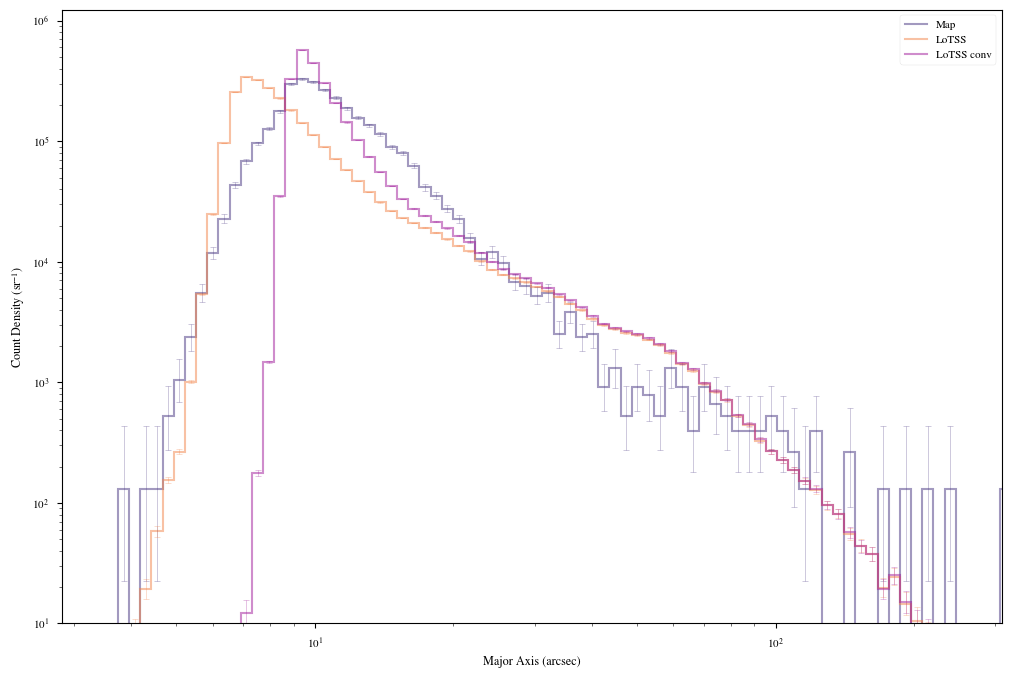

In [103]:
fig_width = 10

fig, ax = plt.subplots(1, 1, figsize=(fig_width, fig_width * 2 / 3), dpi=100)

# Plot data
for cat_name, (cts, err, color) in plot_data.items():
    p = ax.stairs(
        cts,
        bins,
        label=cat_name,
        color=color,
        lw=1.5,
        alpha=0.5,
    )
    ax.errorbar(
        (bins[1:] + bins[:-1]) / 2,
        cts,
        yerr=err,
        ls="none",
        color=p.get_edgecolor(),
        alpha=0.5 * 0.75,
        elinewidth=0.5,
        capsize=2.5,
        capthick=0.5,
    )

# Set x range
xmin, xmax = 3.5e0, 2.5e2
side_gap = 0.05
log_factor = xmax ** (side_gap) * xmin ** (-side_gap)
ax.set_xlim(xmin / log_factor, xmax * log_factor)

# Axis settings
ax.set_xlabel("Major Axis (arcsec)")
ax.set_ylabel("Count Density (sr$^{-1}$)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()
ax.set_ylim(bottom=1e1)

## Residual RMS

In [ ]:
reload(pp)

pp.residual_RMS()

In [ ]:
sub_wcs.wcs.crpix

# Color Choices

In [ ]:
import numpy as np


def cmap_spacing(cmap, n=20):
    spacing = np.linspace(0, 1, n + 1)
    plt.imshow(
        np.ones((1, 21)) * spacing,
        cmap=cmap,
        vmin=0,
        vmax=1,
        extent=[-0.5, n + 0.5, 0, 5],
    )
    ax = plt.gca()
    ax.set_xticks(np.arange(0, n + 1, 1))
    ax.set_xticklabels([f"{s:.2f}" for s in spacing])
    ax.set_yticks([])
    plt.show()

In [ ]:
cmap_spacing("plasma")
cmap_spacing("viridis")